In [9]:
# Imports
import pickle

import jax
import jaxopt
import jax.nn as jnn
import jax.numpy as jnp
from functools import partial

import time as tt
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 18

import os
import corner
import numpy as np
import multiprocessing as mp

import dynesty
import dynesty.utils as dyut

from potentials import *
from integrants import *
from utils import *

from potentials import NFW_acceleration
from densities import MiyamotoNagai_density

from CylindricalSpline import get_phi_m, get_acc, evaluate_phi

from main import *

import time as tt

In [10]:
#Hyperparameters for dynesty
ndim = 5
nlive = 500
PATH_DATA = f'/data/dc824-2/ScharMAX_first_tests'

with open('./IC_axisymmetric_disc.pkl', 'rb') as f:
    ic = pickle.load(f)
index = np.random.choice(10_000, size=10_000, replace=False)
w0 = jnp.array([ic['x'][index], ic['y'][index], ic['z'][index], ic['vx'][index], ic['vy'][index], ic['vz'][index]]).T

with open('./axisymmetric_disc.pkl', 'rb') as f:
    data = pickle.load(f)
w0_data = jnp.array([data['x'], data['y'], data['z'], data['vx'], data['vy'], data['vz']]).T
density_data = histogram3d(w0_data[:, :3], None)

r_data    = jnp.linalg.norm(w0_data[:, :2], axis=-1)
vr_data   = (w0_data[:, 0] * w0_data[:, 3] + w0_data[:, 1] * w0_data[:, 4]) / r_data
vr_data_binned  = histogram3d(w0_data[:, :3], vr_data) / density_data
vr2_data_binned  = histogram3d(w0_data[:, :3], vr_data**2) / density_data
sigmavr_data_binned = jnp.sqrt(vr2_data_binned - vr_data_binned**2)

vphi_data = -(-w0_data[:, 1] * w0_data[:, 3] + w0_data[:, 0] * w0_data[:, 4]) / r_data
vphi_data_binned  = histogram3d(w0_data[:, :3], vphi_data) / density_data
vphi2_data_binned  = histogram3d(w0_data[:, :3], vphi_data**2) / density_data
sigmavphi_data_binned = jnp.sqrt(vphi2_data_binned - vphi_data_binned**2)

vz_data = w0_data[:, 5]
vz_data_binned = histogram3d(w0_data[:, :3], w0_data[:, 5]) / density_data
vz2_data_binned = histogram3d(w0_data[:, :3], vz_data**2) / density_data
sigmavz_data_binned = jnp.sqrt(vz2_data_binned - vz_data_binned**2)

dict_data = {
    'w0': w0,
    'density_data': density_data,
    'vr_data_binned': vr_data_binned,
    'sigmavr_data_binned': sigmavr_data_binned,
    'vphi_data_binned': vphi_data_binned,
    'sigmavphi_data_binned': sigmavphi_data_binned,
    'vz_data_binned': vz_data_binned,
    'sigmavz_data_binned': sigmavz_data_binned
}

In [36]:
p = np.random.uniform(0.0, 1.0, size=(ndim,))
params = prior_transform(p)

# ground_truth = [
#     jnp.log10(0.8*10**12).item(),
#     data['ground_truth']['halo_params']['scaleRadius'],
#     jnp.log10(data['ground_truth']['disc_params']['Sigma0']).item(),
#     data['ground_truth']['disc_params']['Rd'],
#     data['ground_truth']['disc_params']['hz'],
# ]
# params = ground_truth

In [37]:
params_halo_pot = {
    'logM': params[0],
    'Rs':params[1],
    'a':1.0,
    'b':1.0,
    'c':1.0,
    'x_origin':0.0,
    'y_origin':0.0,
    'z_origin':0.0,
    'dirx':0.0,
    'diry':0.0,
    'dirz':1.0
}

params_disk_rho = {
    'logM': params[2],
    'Rs': params[3],
    'Hs': params[4],
    'x_origin': 0.0,
    'y_origin': 0.0,
    'z_origin': 0.0,
    'dirx': 0.0,
    'diry': 0.0,
    'dirz': 1.0
}

In [38]:
NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax = 50, 30, 1e-2, 30.0, 1e-3, 15.0, 5.
Nphi = 200
N_int = 10_000

a = tt.time()
dict_phi = jax.block_until_ready(get_phi_m(MiyamotoNagai_density, params_disk_rho, NR, NZ, Rmin, Rmax, Zmin, Zmax, Mmax, Nphi, N_int))
b = tt.time()
print(f'Time to compute phi_m: {b - a} seconds')

Time to compute phi_m: 4.586598873138428 seconds


In [39]:
@jax.jit
def get_acc(x, y, z, params, eps=1e-3):
    """Return acceleration = -∇phi using central finite differences."""
    def phi(pos):
        return evaluate_phi(pos[0], pos[1], pos[2], params)

    # 6 nearby positions for central differences
    base = jnp.array([x, y, z])
    shifts = jnp.array([
        [ eps, 0.0, 0.0],
        [-eps, 0.0, 0.0],
        [0.0,  eps, 0.0],
        [0.0,-eps, 0.0],
        [0.0, 0.0,  eps],
        [0.0, 0.0,-eps],
    ])
    pts = base + shifts

    # compute phi at the 6 shifted points
    phi_vals = jax.vmap(phi)(pts)

    dphidx = (phi_vals[0] - phi_vals[1]) / (2 * eps)
    dphidy = (phi_vals[2] - phi_vals[3]) / (2 * eps)
    dphidz = (phi_vals[4] - phi_vals[5]) / (2 * eps)

    acc = -jnp.array([dphidx, dphidy, dphidz])
    return acc

@jax.jit
def acc_fn(x, y, z, params_halo_pot, dict_phi):
    a_halo = NFW_acceleration(x, y, z, params_halo_pot)
    a_disk = get_acc(x, y, z, dict_phi)
    return a_halo + a_disk

def _split(w):
    return w[:3], w[3:]

def _merge(r, v):
    return jnp.concatenate([r, v], axis=0)

@partial(jax.jit, static_argnames=('acc_fn', 'n_steps', 'unroll'))
def integrate_leapfrog_traj(w0, acc_fn, params_halo_pot, dict_phi, n_steps, dt = 0.010, t0 = 0.0, unroll=True):
    """Leapfrog (KDK) — returns final time and final state only."""

    def step(carry, _):
        t, y = carry
        r, v = _split(y)

        # params['t'] = t  # Update time-dependent parameters
        a0 = acc_fn(*r, params_halo_pot, dict_phi) # , params)
        v_half = v + 0.5 * dt * a0
        r_new = r + dt * v_half
        t_new = t + dt

        # params['t'] = t_new  # Update time-dependent parameters
        a1 = acc_fn(*r_new, params_halo_pot, dict_phi) # , params)
        v_new = v_half + 0.5 * dt * a1
        y_new = _merge(r_new, v_new)
        return (t_new, y_new), (t_new, y_new)

    (_, _), (tN, wN) = jax.lax.scan(step, (t0, w0), xs=None, length=n_steps, unroll=unroll)
    return tN, wN

time = 2. #Gyr
n_steps = 1000
dt = time / n_steps
unroll = False
initial_time = 0.0

a = tt.time()
time, xv = jax.block_until_ready(
                jax.vmap(integrate_leapfrog_traj, in_axes=(0, None, None, None, None, None, None, None))(dict_data['w0'], acc_fn, params_halo_pot, dict_phi, n_steps, dt, initial_time, unroll)
            )
b = tt.time()
print(f'Time to compute xv: {b - a} seconds')

Time to compute xv: 8.46414828300476 seconds


In [40]:
density_model = jax.block_until_ready(jax.vmap(histogram3d)(xv[:, :, :3], None))

(-10.0, 10.0)

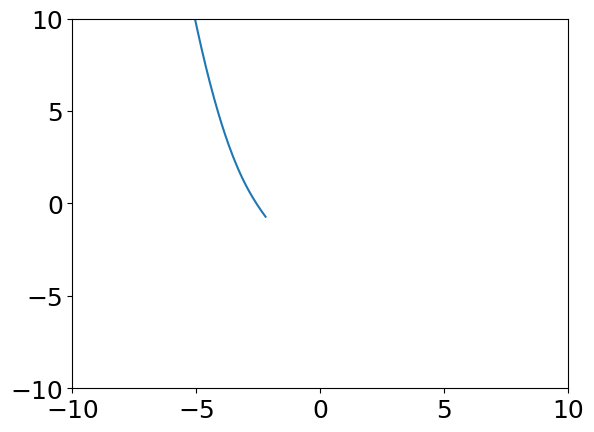

In [69]:
i = np.random.randint(len(xv))
plt.plot(xv[i, :, 0], xv[i, :, 1])
plt.xlim(-10,10)
plt.ylim(-10,10)

In [74]:
A = density_model.reshape(len(xv), -1).T.astype(jnp.float32)/n_steps
y = dict_data['density_data'].reshape(-1).astype(jnp.float32)
sig = jnp.maximum(0.1*y, 1.) #jnp.sqrt(y + 1.0).astype(jnp.float32)  # Poisson noise + 1.0 floor

@jax.jit
def _nll_z(z, A, y, sig, l2):
    x = jnn.softplus(z)  # strictly positive
    r = (A @ x - y) / sig
    return 0.5 * jnp.dot(r, r) + 0.5 * l2 * jnp.dot(x, x)
_nll_z = jax.value_and_grad(_nll_z)

@jax.jit
def solve_lbfgs_softplus(A, y, sigma, l2=1e-3, maxiter=500, tol=1e-6):
    z0 = jnp.zeros(A.shape[1], A.dtype)
    solver = jaxopt.LBFGS(fun=_nll_z, value_and_grad=True, maxiter=maxiter, tol=tol)
    res = solver.run(z0, A, y, sigma, l2)
    x_hat = jnn.softplus(res.params)
    return x_hat

weights = jax.block_until_ready(solve_lbfgs_softplus(A, y, sig, l2=1e-3, maxiter=300))

In [75]:
weights_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), jnp.repeat(weights, n_steps).ravel())

r_model    = jnp.linalg.norm(xv[:, :, :2], axis=-1)
vr_model   = (xv[:, :, 0] * xv[:, :, 3] + xv[:, :, 1] * xv[:, :, 4]) / r_model
vr_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model*weights[:, None]).ravel())/(weights_binned+EPSILON)
vr2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vr_model**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
sigmavr_binned = jnp.sqrt(jnp.clip(vr2_binned - vr_binned**2, a_min=0.0))

vphi = -(-xv[:, :, 1] * xv[:, :, 3] + xv[:, :, 0] * xv[:, :, 4]) / r_model
vphi_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi*weights[:, None]).ravel())/(weights_binned+EPSILON)
vphi2_binned  = histogram3d(xv[:, :, :3].reshape(-1, 3), (vphi**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
sigmavphi_binned = jnp.sqrt(jnp.clip(vphi2_binned - vphi_binned**2, a_min=0.0))

vz_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]*weights[:, None]).ravel())/(weights_binned+EPSILON)
vz2_binned = histogram3d(xv[:, :, :3].reshape(-1, 3), (xv[:, :, 5]**2 * weights[:, None]).ravel())/(weights_binned+EPSILON)
sigmavz_binned = jnp.sqrt(jnp.clip(vz2_binned - vz_binned**2, a_min=0.0))

In [204]:
from CylindricalSpline import evaluate_phi

In [258]:
x, y, z = np.random.uniform(-15.0, 15.0, size=(3,10000000))
jax.vmap(get_acc, in_axes=(0,0,0,None))(x,y,z,dict_phi)


Array([[ 11.112296  ,  -7.787594  , -11.954057  ],
       [-11.539855  ,   0.6458215 ,  10.365064  ],
       [-21.082642  ,  -5.2926607 , -20.447458  ],
       ...,
       [ -4.2000866 ,   0.47315916,  14.092494  ],
       [  8.510197  , -12.505363  ,   3.2917485 ],
       [-26.121     ,   3.6476636 , -14.536548  ]], dtype=float32)

In [259]:
(jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x-0.0005,y,z,dict_phi) - jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x+0.0005,y,z,dict_phi))/0.001
(jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x,y-0.0005,z,dict_phi) - jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x,y+0.0005,z,dict_phi))/0.001
(jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x,y,z-0.0005,dict_phi) - jax.vmap(evaluate_phi, in_axes=(0,0,0,None))(x,y,z+0.0005,dict_phi))/0.001

Array([-11.96289  ,  10.345458 , -20.446775 , ...,  14.114379 ,
         3.2653806, -14.526366 ], dtype=float32)

In [262]:
x, y, z = np.random.uniform(-15.0, 15.0, size=(3,100000000))
jax.vmap(NFW_acceleration, in_axes=(0,0,0,None))(x,y,z,params_halo_pot)

Array([[  445.23807,   236.67386,  2179.072  ],
       [-1143.8875 ,   604.60535, -1340.3097 ],
       [ 3012.3752 ,   281.42224,  1897.5509 ],
       ...,
       [  886.3934 ,  -961.6822 , -1313.4652 ],
       [-1530.0061 ,  2342.5764 ,   335.14432],
       [  315.74692,  1218.9612 ,  1414.8116 ]], dtype=float32)

In [265]:
(jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x-0.0005,y,z,params_halo_pot) - jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x+0.0005,y,z,params_halo_pot))/0.001
(jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x,y-0.0005,z,params_halo_pot) - jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x,y+0.0005,z,params_halo_pot))/0.001
(jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x,y,z-0.0005,params_halo_pot) - jax.vmap(NFW_potential, in_axes=(0,0,0,None))(x,y,z+0.0005,params_halo_pot))/0.001

Array([ 2171.875  , -1351.5624 ,  1874.9999 , ..., -1304.6874 ,
         343.74997,  1406.2499 ], dtype=float32)